In [1]:
import pandas as pd
file_path = r"C:\Users\pande\CreditRisk\Dataset\credit_risk_dataset.csv"
df = pd.read_csv(file_path)


In [2]:
df.shape

(32581, 12)

In [3]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_age,32581.0,NaN,NaN,NaN,27.7346,6.348078,20.0,23.0,26.0,30.0,144.0
person_income,32581.0,NaN,NaN,NaN,66074.84847,61983.119168,4000.0,38500.0,55000.0,79200.0,6000000.0
person_home_ownership,32581,4,RENT,16446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_emp_length,31686.0,NaN,NaN,NaN,4.789686,4.14263,0.0,2.0,4.0,7.0,123.0
loan_intent,32581,6,EDUCATION,6453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_grade,32581,7,A,10777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,32581.0,NaN,NaN,NaN,9589.371106,6322.086646,500.0,5000.0,8000.0,12200.0,35000.0
loan_int_rate,29465.0,NaN,NaN,NaN,11.011695,3.240459,5.42,7.9,10.99,13.47,23.22
loan_status,32581.0,NaN,NaN,NaN,0.218164,0.413006,0.0,0.0,0.0,0.0,1.0
loan_percent_income,32581.0,NaN,NaN,NaN,0.170203,0.106782,0.0,0.09,0.15,0.23,0.83


In [6]:
df.duplicated().sum()

np.int64(165)

In [7]:
df.isnull().mean() * 100

person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
person_emp_length             2.747000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_int_rate                 9.563856
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64

In [8]:
df["person_emp_length"].fillna(
    df["person_emp_length"].median(),
    inplace=True
)

C:\Users\pande\AppData\Local\Temp\ipykernel_26832\2575608120.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["person_emp_length"].fillna(


In [9]:
df["loan_int_rate"] = df.groupby("loan_grade")["loan_int_rate"].transform(
    lambda x: x.fillna(x.median())
)

In [10]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [11]:
df[df.duplicated(keep=False)].sort_values(
    by=list(df.columns)
)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
15944,21,8088,RENT,4.0,MEDICAL,C,1200,15.23,0,0.15,Y,2
16835,21,8088,RENT,4.0,MEDICAL,C,1200,15.23,0,0.15,Y,2
2431,21,15600,RENT,0.0,MEDICAL,A,2800,7.40,1,0.18,N,4
17758,21,15600,RENT,0.0,MEDICAL,A,2800,7.40,1,0.18,N,4
2498,21,18000,RENT,0.0,DEBTCONSOLIDATION,A,3000,7.90,1,0.17,N,2
...,...,...,...,...,...,...,...,...,...,...,...,...
32010,42,39996,MORTGAGE,2.0,HOMEIMPROVEMENT,A,2500,5.42,0,0.06,N,12
29484,43,11340,RENT,4.0,EDUCATION,C,1950,13.48,1,0.17,N,11
32279,43,11340,RENT,4.0,EDUCATION,C,1950,13.48,1,0.17,N,11
31676,49,120000,MORTGAGE,12.0,MEDICAL,B,12000,10.99,0,0.10,N,12


In [12]:
df = df.drop_duplicates()

In [13]:
print("Duplicate rows:", df.duplicated().sum())
print("New shape:", df.shape)

Duplicate rows: 0
New shape: (32416, 12)


In [14]:
df = df.drop_duplicates().reset_index(drop=True)

In [15]:
class_dist = pd.DataFrame({
    "Count": df["loan_status"].value_counts(),
    "Percentage": df["loan_status"].value_counts(normalize=True) * 100
})

class_dist

,Count,Percentage
loan_status,,
0,25327,78.13117
1,7089,21.86883


In [16]:
from sklearn.model_selection import train_test_split, StratifiedKFold

# 1. Features and Target
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

# 2. Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# 3. Stratified K-Fold
skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# 4. Generate and store all 10 folds
folds = list(skf.split(X_train, y_train))

print(f"Total folds: {len(folds)}")

for fold, (train_idx, val_idx) in enumerate(folds, 1):
    print(
        f"Fold {fold}: "
        f"Train = {len(train_idx)}, "
        f"Validation = {len(val_idx)}"
    )

Total folds: 10
Fold 1: Train = 23338, Validation = 2594
Fold 2: Train = 23338, Validation = 2594
Fold 3: Train = 23339, Validation = 2593
Fold 4: Train = 23339, Validation = 2593
Fold 5: Train = 23339, Validation = 2593
Fold 6: Train = 23339, Validation = 2593
Fold 7: Train = 23339, Validation = 2593
Fold 8: Train = 23339, Validation = 2593
Fold 9: Train = 23339, Validation = 2593
Fold 10: Train = 23339, Validation = 2593


In [17]:
# COMMON PREPROCESSING

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical columns
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Categorical columns
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

# Numerical preprocessing
numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combined preprocessing
preprocessor = ColumnTransformer([
    ("numerical", numeric_preprocessor, numeric_features),
    ("categorical", categorical_preprocessor, categorical_features)
])

print("Numerical columns:", numeric_features)
print("Categorical columns:", categorical_features)

Numerical columns: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
Categorical columns: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


In [18]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [19]:
# BASELINE MODEL: LOGISTIC REGRESSION
# 10-FOLD TRAIN + VALIDATION + EVALUATION

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
import pandas as pd

# Baseline model
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

fold_results = []

# Use the 10 folds already stored in `folds`
for fold, (train_idx, val_idx) in enumerate(folds, 1):

    # Get train and validation data for this fold
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # Fresh model for each fold
    model = clone(baseline_model)

    # Train
    model.fit(X_fold_train, y_fold_train)

    # Validation predictions
    y_pred = model.predict(X_fold_val)
    y_prob = model.predict_proba(X_fold_val)[:, 1]

    # Validation metrics
    fold_results.append({
        "Fold": fold,
        "Accuracy": accuracy_score(y_fold_val, y_pred),
        "Precision": precision_score(y_fold_val, y_pred, zero_division=0),
        "Recall": recall_score(y_fold_val, y_pred, zero_division=0),
        "F1": f1_score(y_fold_val, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_fold_val, y_prob),
        "PR_AUC": average_precision_score(y_fold_val, y_prob)
    })

# Fold-wise results
fold_results = pd.DataFrame(fold_results)

print("10-FOLD VALIDATION RESULTS")
display(fold_results)

# Mean ± Std
print("\nMEAN ± STD")
display(
    fold_results.drop(columns="Fold").agg(["mean", "std"]).T
)

10-FOLD VALIDATION RESULTS


,Fold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,1,0.809175,0.544444,0.777778,0.640523,0.869509,0.709606
1,2,0.818813,0.563472,0.765845,0.649254,0.866626,0.706968
2,3,0.801388,0.531553,0.772487,0.629763,0.861727,0.713340
3,4,0.801774,0.532756,0.760141,0.626453,0.862208,0.705372
4,5,0.808716,0.542720,0.795414,0.645207,0.872881,0.709618
5,6,0.812187,0.548780,0.793651,0.648882,0.875338,0.735967
6,7,0.806402,0.539490,0.783069,0.638849,0.874257,0.716165
7,8,0.821057,0.566970,0.768959,0.652695,0.876064,0.725282
8,9,0.807944,0.544402,0.746032,0.629464,0.864541,0.700621
9,10,0.818743,0.558646,0.814815,0.662841,0.886750,0.743108



MEAN ± STD


,mean,std
Accuracy,0.810620,0.006981
Precision,0.547323,0.012190
Recall,0.777819,0.019804
F1,0.642393,0.011634
ROC_AUC,0.870990,0.007696
PR_AUC,0.716605,0.013887


In [20]:
# MODEL 2: RANDOM FOREST CLASSIFIER
# 10-FOLD TRAIN + VALIDATION + EVALUATION

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
import pandas as pd

# Random Forest model
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

fold_results_rf = []

# Use the SAME 10 folds
for fold, (train_idx, val_idx) in enumerate(folds, 1):

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # Fresh model for each fold
    model = clone(random_forest_model)

    # Train
    model.fit(X_fold_train, y_fold_train)

    # Validation predictions
    y_pred = model.predict(X_fold_val)
    y_prob = model.predict_proba(X_fold_val)[:, 1]

    # Evaluation
    fold_results_rf.append({
        "Fold": fold,
        "Accuracy": accuracy_score(y_fold_val, y_pred),
        "Precision": precision_score(y_fold_val, y_pred, zero_division=0),
        "Recall": recall_score(y_fold_val, y_pred, zero_division=0),
        "F1": f1_score(y_fold_val, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_fold_val, y_prob),
        "PR_AUC": average_precision_score(y_fold_val, y_prob)
    })

# Fold-wise results
fold_results_rf = pd.DataFrame(fold_results_rf)

print("RANDOM FOREST — 10-FOLD VALIDATION RESULTS")
display(fold_results_rf)

# Mean ± Std
print("\nMEAN ± STD")
display(
    fold_results_rf.drop(columns="Fold").agg(["mean", "std"]).T
)

RANDOM FOREST — 10-FOLD VALIDATION RESULTS


,Fold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,1,0.926369,0.910480,0.735450,0.813659,0.933561,0.883683
1,2,0.925598,0.903226,0.739437,0.813166,0.933893,0.885268
2,3,0.926726,0.908894,0.738977,0.815175,0.930663,0.881334
3,4,0.926340,0.893305,0.753086,0.817225,0.927989,0.880508
4,5,0.922098,0.899344,0.724868,0.802734,0.934725,0.879786
5,6,0.931739,0.927632,0.746032,0.826979,0.931029,0.884813
6,7,0.934053,0.905738,0.779541,0.837915,0.937332,0.895619
7,8,0.922869,0.906874,0.721340,0.803536,0.922959,0.867571
8,9,0.920941,0.891775,0.726631,0.800777,0.928416,0.873035
9,10,0.932125,0.908142,0.767196,0.831740,0.941653,0.900640



MEAN ± STD


,mean,std
Accuracy,0.926886,0.004460
Precision,0.905541,0.010084
Recall,0.743256,0.018805
F1,0.816291,0.012589
ROC_AUC,0.932222,0.005249
PR_AUC,0.883226,0.009635


In [21]:
# MODEL 3: XGBOOST CLASSIFIER
# 10-FOLD TRAIN + VALIDATION + EVALUATION

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
import pandas as pd

# XGBoost model
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

fold_results_xgb = []

# Use the SAME 10 stored folds
for fold, (train_idx, val_idx) in enumerate(folds, 1):

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # Fresh model for each fold
    model = clone(xgb_model)

    # Train
    model.fit(X_fold_train, y_fold_train)

    # Validation predictions
    y_pred = model.predict(X_fold_val)
    y_prob = model.predict_proba(X_fold_val)[:, 1]

    # Evaluation
    fold_results_xgb.append({
        "Fold": fold,
        "Accuracy": accuracy_score(y_fold_val, y_pred),
        "Precision": precision_score(y_fold_val, y_pred, zero_division=0),
        "Recall": recall_score(y_fold_val, y_pred, zero_division=0),
        "F1": f1_score(y_fold_val, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_fold_val, y_prob),
        "PR_AUC": average_precision_score(y_fold_val, y_prob)
    })

# Fold-wise results
fold_results_xgb = pd.DataFrame(fold_results_xgb)

print("XGBOOST — 10-FOLD VALIDATION RESULTS")
display(fold_results_xgb)

# Mean ± Std
print("\nMEAN ± STD")
display(
    fold_results_xgb.drop(columns="Fold").agg(["mean", "std"]).T
)

XGBOOST — 10-FOLD VALIDATION RESULTS


,Fold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,1,0.936777,0.976359,0.728395,0.834343,0.946316,0.901745
1,2,0.936777,0.971963,0.732394,0.835341,0.949736,0.908406
2,3,0.935981,0.967366,0.731922,0.833333,0.944871,0.901560
3,4,0.936367,0.971831,0.730159,0.833837,0.943987,0.896841
4,5,0.931739,0.964286,0.714286,0.820669,0.945988,0.897067
5,6,0.938681,0.976636,0.737213,0.840201,0.947288,0.906602
6,7,0.944080,0.977376,0.761905,0.856293,0.952875,0.913738
7,8,0.929811,0.970660,0.700176,0.813525,0.941429,0.890056
8,9,0.931739,0.982673,0.700176,0.817714,0.946372,0.899178
9,10,0.939452,0.965909,0.749559,0.844091,0.954548,0.913636



MEAN ± STD


,mean,std
Accuracy,0.936141,0.004218
Precision,0.972506,0.005780
Recall,0.728619,0.019639
F1,0.832935,0.012869
ROC_AUC,0.947341,0.004006
PR_AUC,0.902883,0.007670


In [22]:
# XGBOOST HYPERPARAMETER TUNING

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV

xgb_tuning_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

param_grid = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__gamma": [0, 0.1, 0.3, 0.5]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_tuning_model,
    param_distributions=param_grid,
    n_iter=30,
    scoring="accuracy",
    cv=folds,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    refit=False
)

xgb_search.fit(X_train, y_train)

print("BEST PARAMETERS:")
print(xgb_search.best_params_)

print("\nBEST CV ACCURACY:")
print(xgb_search.best_score_)

Fitting 10 folds for each of 30 candidates, totalling 300 fits
BEST PARAMETERS:
{'model__subsample': 0.9, 'model__n_estimators': 500, 'model__min_child_weight': 1, 'model__max_depth': 8, 'model__learning_rate': 0.03, 'model__gamma': 0.5, 'model__colsample_bytree': 0.7}

BEST CV ACCURACY:
0.9365647861019571


In [23]:
# TRAIN FINAL XGBOOST ON COMPLETE X_TRAIN

final_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

# Apply best hyperparameters
final_xgb.set_params(**xgb_search.best_params_)

# Train on COMPLETE training set
final_xgb.fit(X_train, y_train)

print("Final XGBoost trained on complete X_train.")

Final XGBoost trained on complete X_train.


In [24]:
# SAVE FINAL XGBOOST MODEL

import joblib
model_path = r"C:\Users\pande\CreditRisk\AI\final_credit_risk_xgboost.pkl"
joblib.dump(final_xgb, model_path)
print(f"Model saved successfully: {model_path}")

Model saved successfully: C:\Users\pande\CreditRisk\AI\final_credit_risk_xgboost.pkl


In [25]:
# FINAL TEST SET EVALUATION

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Predict on completely untouched test set
y_test_pred = final_xgb.predict(X_test)
y_test_prob = final_xgb.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_test_prob)
pr_auc = average_precision_score(y_test, y_test_prob)

print("FINAL XGBOOST — TEST SET RESULTS")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")

print("\nCONFUSION MATRIX:")
print(confusion_matrix(y_test, y_test_pred))

print("\nCLASSIFICATION REPORT:")
print(classification_report(
    y_test,
    y_test_pred,
    digits=4
))

FINAL XGBOOST — TEST SET RESULTS
Accuracy  : 0.9382
Precision : 0.9766
Recall    : 0.7348
F1 Score  : 0.8386
ROC-AUC   : 0.9510
PR-AUC    : 0.9098

CONFUSION MATRIX:
[[5041   25]
 [ 376 1042]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0     0.9306    0.9951    0.9617      5066
           1     0.9766    0.7348    0.8386      1418

    accuracy                         0.9382      6484
   macro avg     0.9536    0.8650    0.9002      6484
weighted avg     0.9406    0.9382    0.9348      6484



In [26]:
# STEP 4 — THRESHOLD OPTIMIZATION
# USING EXISTING 10 STRATIFIED FOLDS

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Store out-of-fold probabilities
oof_prob = np.zeros(len(X_train))

# Generate predictions for each validation fold
for fold, (train_idx, val_idx) in enumerate(folds, 1):

    # Fold data
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]

    # Fresh copy of final/best-parameter model
    fold_model = clone(final_xgb)

    # Train only on fold training data
    fold_model.fit(X_fold_train, y_fold_train)

    # Probability for class 1
    oof_prob[val_idx] = fold_model.predict_proba(
        X_fold_val
    )[:, 1]

# FIND BEST THRESHOLD FOR ACCURACY

thresholds = np.arange(0.10, 0.91, 0.01)

threshold_results = []

for threshold in thresholds:

    y_oof_pred = (oof_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_train, y_oof_pred),
        "Precision": precision_score(
            y_train, y_oof_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_train, y_oof_pred, zero_division=0
        ),
        "F1": f1_score(
            y_train, y_oof_pred, zero_division=0
        )
    })

threshold_results = pd.DataFrame(threshold_results)

# Best threshold based ONLY on OOF accuracy
best_threshold_row = threshold_results.loc[
    threshold_results["Accuracy"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("BEST THRESHOLD")

print(f"Threshold : {best_threshold:.2f}")
print(f"Accuracy  : {best_threshold_row['Accuracy']:.4f}")
print(f"Precision : {best_threshold_row['Precision']:.4f}")
print(f"Recall    : {best_threshold_row['Recall']:.4f}")
print(f"F1 Score  : {best_threshold_row['F1']:.4f}")

print("\nALL THRESHOLD RESULTS:")
display(threshold_results)

BEST THRESHOLD
Threshold : 0.48
Accuracy  : 0.9367
Precision : 0.9666
Recall    : 0.7358
F1 Score  : 0.8356

ALL THRESHOLD RESULTS:


,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.821880,0.556914,0.907600,0.690270
1,0.11,0.836110,0.581154,0.897196,0.705393
2,0.12,0.847910,0.603749,0.886087,0.718165
3,0.13,0.859479,0.627886,0.877447,0.731980
4,0.14,0.869235,0.650555,0.868630,0.743940
...,...,...,...,...,...
76,0.86,0.929585,0.999221,0.678540,0.808234
77,0.87,0.928930,0.999218,0.675542,0.806102
78,0.88,0.927965,0.999475,0.670958,0.802912
79,0.89,0.926654,0.999470,0.664962,0.798602


In [27]:
# FINAL TEST EVALUATION WITH BEST THRESHOLD

# Test probabilities
y_test_prob = final_xgb.predict_proba(X_test)[:, 1]

# Apply validation-selected threshold
y_test_pred_threshold = (
    y_test_prob >= best_threshold
).astype(int)

print("FINAL TEST RESULTS — OPTIMIZED THRESHOLD")

print(
    f"Accuracy  : "
    f"{accuracy_score(y_test, y_test_pred_threshold):.4f}"
)

print(
    f"Precision : "
    f"{precision_score(y_test, y_test_pred_threshold, zero_division=0):.4f}"
)

print(
    f"Recall    : "
    f"{recall_score(y_test, y_test_pred_threshold, zero_division=0):.4f}"
)

print(
    f"F1 Score  : "
    f"{f1_score(y_test, y_test_pred_threshold, zero_division=0):.4f}"
)

FINAL TEST RESULTS — OPTIMIZED THRESHOLD
Accuracy  : 0.9380
Precision : 0.9739
Recall    : 0.7362
F1 Score  : 0.8386


In [28]:
# ERROR ANALYSIS — FINAL TEST SET

error_analysis = X_test.copy()

error_analysis["Actual"] = y_test.values
error_analysis["Predicted"] = y_test_pred_threshold
error_analysis["Probability"] = y_test_prob

# Only misclassified rows
errors = error_analysis[
    error_analysis["Actual"] != error_analysis["Predicted"]
].copy()

print("Total test samples:", len(X_test))
print("Misclassified:", len(errors))
print(
    "Error rate:",
    len(errors) / len(X_test)
)

print("\nMISCLASSIFIED SAMPLES:")
display(errors.head(20))

Total test samples: 6484
Misclassified: 402
Error rate: 0.06199876619370759

MISCLASSIFIED SAMPLES:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,Actual,Predicted,Probability
26854,30,108000,MORTGAGE,0.0,DEBTCONSOLIDATION,B,4925,10.99,0.05,N,9,1,0,0.050260
10819,22,36000,RENT,4.0,PERSONAL,B,10000,11.36,0.28,N,2,1,0,0.145203
28093,28,41000,RENT,11.0,VENTURE,E,4000,18.64,0.10,Y,5,1,0,0.288289
31205,37,78000,MORTGAGE,0.0,PERSONAL,B,5600,10.74,0.07,N,12,1,0,0.140559
7843,26,36000,RENT,4.0,MEDICAL,C,7000,13.98,0.19,Y,2,1,0,0.115933
3127,22,29554,MORTGAGE,4.0,DEBTCONSOLIDATION,A,5775,5.42,0.20,N,3,1,0,0.084902
20439,28,88000,RENT,3.0,PERSONAL,B,10000,10.65,0.11,N,9,1,0,0.031561
15495,23,56525,RENT,1.0,MEDICAL,B,15000,11.48,0.23,N,4,1,0,0.177203
32083,40,52479,RENT,17.0,HOMEIMPROVEMENT,D,6600,14.54,0.13,N,17,1,0,0.396415
27886,28,33000,RENT,12.0,PERSONAL,C,8000,14.65,0.24,N,9,1,0,0.280122


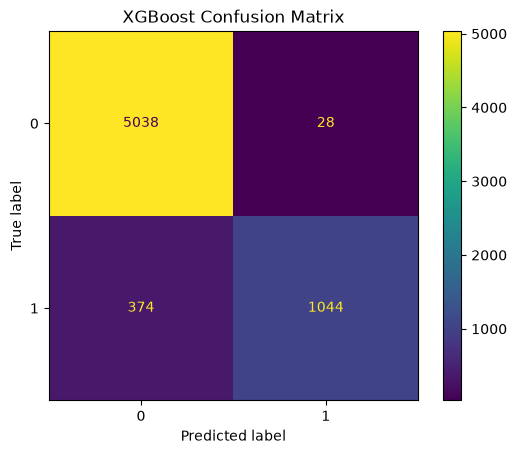

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_threshold
)

plt.title("XGBoost Confusion Matrix")
plt.show()

In [30]:
#feature distribution of erros
numeric_cols = X_test.select_dtypes(
    include=["int64", "float64"]
).columns

display(
    errors[numeric_cols].describe().T
)

,count,mean,std,min,25%,50%,75%,max
person_age,402.0,27.584577,5.811594,21.00,24.00,26.000,30.00,54.00
person_income,402.0,59944.320896,46276.147596,8088.00,36000.00,49000.000,70000.00,604000.00
person_emp_length,402.0,5.263682,4.283020,0.00,2.00,4.000,7.00,21.00
loan_amnt,402.0,9279.166667,6612.024516,1000.00,4200.00,8000.000,12000.00,35000.00
loan_int_rate,402.0,11.964950,3.069441,5.42,9.91,12.175,13.99,19.91
loan_percent_income,402.0,0.168905,0.105369,0.02,0.08,0.150,0.23,0.58
cb_person_cred_hist_length,402.0,5.781095,3.840568,2.00,3.00,4.000,8.00,24.00
